In [1]:
"""
=====================================================================
 INGESTÃO DE DADOS — Painel Inteligente de Acesso Hospitalar
 Challenge Oracle + FIAP / 1TSCO
=====================================================================
 Baixa e prepara as TRÊS fontes do desafio, gera os arquivos finais
 e empacota num .zip para você BAIXAR do Colab e subir manualmente
 no bucket OCI (datalake-datascience) pela interface web.

 Fluxo: Colab baixa+trata  ->  você baixa o .zip  ->  arrasta no
        console OCI (Object Storage > datalake-datascience).

 COMO USAR NO COLAB:
   1. Cole este código numa célula (ou suba como .py e rode).
   2. Rode a célula de instalação primeiro (abaixo).
   3. Rode o script. No fim, baixe o arquivo dados_painel.zip.
=====================================================================
"""

'\n=====================================================================\n INGESTÃO DE DADOS — Painel Inteligente de Acesso Hospitalar\n Challenge Oracle + FIAP / 1TSCO\n=====================================================================\n Baixa e prepara as TRÊS fontes do desafio, gera os arquivos finais\n e empacota num .zip para você BAIXAR do Colab e subir manualmente\n no bucket OCI (datalake-datascience) pela interface web.\n\n Fluxo: Colab baixa+trata  ->  você baixa o .zip  ->  arrasta no\n        console OCI (Object Storage > datalake-datascience).\n\n COMO USAR NO COLAB:\n   1. Cole este código numa célula (ou suba como .py e rode).\n   2. Rode a célula de instalação primeiro (abaixo).\n   3. Rode o script. No fim, baixe o arquivo dados_painel.zip.\n=====================================================================\n'

In [3]:
!pip install pysus pandas pyarrow requests

In [4]:
import os
import json
import time
import shutil
import requests
import pandas as pd
from pathlib import Path

/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.6.0)/charset_normalizer (3.4.9) doesn't match a supported version!
  warnings.warn(


### CONFIGURAÇÃO — ajuste o recorte do projeto aqui

In [ ]:
UFS   = ["SP", "RJ"]              # 2 estados (recorte enxuto, proposital)
ANO   = 2024                      # ano de competência
MESES = [1, 2, 3, 4, 5, 6]        # 1º semestre

# Pastas locais (espelham a arquitetura medallion do datalake-datascience)
BASE      = Path("dados_painel")
RAW       = BASE / "raw"          # como veio da fonte
PROCESSED = BASE / "processed"    # tratado / pronto para o bucket
for p in (RAW, PROCESSED):
    p.mkdir(parents=True, exist_ok=True)

### FONTE 1 — SIH/SUS (AIH Reduzida = "RD"). Estruturado
#### Processa UF/mês um de cada vez e libera memória (evita estouro de RAM).

In [ ]:
"""
=====================================================================
 RE-INGESTÃO ROBUSTA DO SIH — SP + RJ, 6 meses cada
=====================================================================
 Corrige o problema da carga anterior (meses sumindo silenciosamente).
 Estratégia: baixa 1 mês por vez, salva cada um como arquivo SEPARADO,
 e mostra no fim EXATAMENTE quais meses entraram e quais falharam.

 Você sobe os 12 arquivos no bucket; o Autonomous carrega todos juntos.

 Instalação (se a sessão for nova):
   !pip install pysus pandas pyarrow
   (depois REINICIE a sessão: Ambiente de execução > Reiniciar sessão)
=====================================================================
"""
import gc
import time
import pandas as pd
from pathlib import Path
from pysus import sih

# ---------------- CONFIG ----------------
UFS   = ["SP", "RJ"]
ANO   = 2024
MESES = [1, 2, 3, 4, 5, 6]

OUT = Path("sih_mensal")
OUT.mkdir(exist_ok=True)

COLS = {
    "ANO_CMPT": "ano", "MES_CMPT": "mes",
    "MUNIC_RES": "municipio_residencia", "MUNIC_MOV": "municipio_hospital",
    "DIAS_PERM": "dias_permanencia", "VAL_TOT": "valor_total",
    "DIAG_PRINC": "cid_principal", "CNES": "cnes",
    "MORTE": "obito",
}

def baixar_mes(uf, mes, tentativas=3):
    """Baixa 1 UF/mês com retry. Retorna nº de linhas salvas (0 se falhou)."""
    destino = OUT / f"sih_{uf}_{ANO}_{mes:02d}.parquet"
    if destino.exists():
        n = len(pd.read_parquet(destino))
        print(f"  {uf} {mes:02d}: já existe ({n:,} linhas) — pulando download")
        return n

    for tentativa in range(1, tentativas + 1):
        try:
            df = sih(state=uf, year=ANO, month=mes)
            existentes = {k: v for k, v in COLS.items() if k in df.columns}
            if len(existentes) < 5 or len(df) == 0:
                print(f"  {uf} {mes:02d}: SEM COLUNAS/VAZIO (tentativa {tentativa})")
                del df; gc.collect()
                time.sleep(2)
                continue
            df = df[list(existentes)].rename(columns=existentes)
            df["uf"] = uf
            for c in ["dias_permanencia", "valor_total", "obito", "mes", "ano"]:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")
            n = len(df)
            df.to_parquet(destino, index=False)
            del df; gc.collect()
            print(f"  {uf} {mes:02d}: OK  ({n:,} linhas)")
            return n
        except Exception as e:
            print(f"  {uf} {mes:02d}: ERRO tentativa {tentativa}: {str(e)[:80]}")
            time.sleep(3)
    print(f"  {uf} {mes:02d}: >>> FALHOU após {tentativas} tentativas <<<")
    return 0


def main():
    print("=" * 60)
    print(" RE-INGESTÃO SIH — SP + RJ, 6 meses (robusta)")
    print("=" * 60)

    resumo = {}
    for uf in UFS:
        print(f"\n[{uf}]")
        for mes in MESES:
            resumo[f"{uf}_{mes:02d}"] = baixar_mes(uf, mes)

    print("\n" + "=" * 60)
    print(" RESUMO FINAL — confira se TODOS os 12 vieram")
    print("=" * 60)
    total = 0
    faltando = []
    for chave, n in resumo.items():
        marca = "OK " if n > 0 else "FALHOU"
        print(f"  {chave}: {n:>8,}  [{marca}]")
        total += n
        if n == 0:
            faltando.append(chave)

    print(f"\n  TOTAL: {total:,} internações")
    print(f"  Arquivos em: {OUT}/  ({len(list(OUT.glob('*.parquet')))} arquivos)")
    if faltando:
        print(f"\n  ATENÇÃO: estes meses FALHARAM e precisam ser refeitos:")
        for f in faltando:
            print(f"    - {f}")
        print("  Rode o script de novo — ele pula os que já vieram e tenta só os que faltam.")
    else:
        print("\n  TODOS os 12 meses vieram completos! Pode zipar e subir.")
        # zipa só se estiver tudo certo
        import shutil
        shutil.make_archive("sih_completo", "zip", OUT)
        print("  Arquivo sih_completo.zip gerado.")
        try:
            from google.colab import files
            files.download("sih_completo.zip")
        except Exception:
            pass


if __name__ == "__main__":
    main()

# ---------------------------------------------------------------
# DEPOIS DE BAIXAR TUDO:
# 1. Baixe sih_completo.zip, descompacte -> 12 arquivos .parquet
# 2. Suba os 12 no bucket em challenge/processed/sih/  (nova subpasta)
# 3. No SQL Web, recarregue a tabela apontando para a PASTA inteira:
#    (o COPY_DATA aceita * para pegar todos os arquivos de uma vez)
# ---------------------------------------------------------------

 RE-INGESTÃO SIH — SP + RJ, 6 meses (robusta)

[SP]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  SP 01: SEM COLUNAS/VAZIO (tentativa 1)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  SP 01: SEM COLUNAS/VAZIO (tentativa 2)


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  RJ 05: SEM COLUNAS/VAZIO (tentativa 2)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  RJ 05: SEM COLUNAS/VAZIO (tentativa 3)
  RJ 05: >>> FALHOU após 3 tentativas <<<


  RJ 06: OK  (3,592 linhas)

 RESUMO FINAL — confira se TODOS os 12 vieram
  SP_01:        0  [FALHOU]
  SP_02:  221,117  [OK ]
  SP_03:        0  [FALHOU]
  SP_04:        0  [FALHOU]
  SP_05:        0  [FALHOU]
  SP_06:  240,552  [OK ]
  RJ_01:        0  [FALHOU]
  RJ_02:        0  [FALHOU]
  RJ_03:        0  [FALHOU]
  RJ_04:        0  [FALHOU]
  RJ_05:        0  [FALHOU]
  RJ_06:    3,592  [OK ]

  TOTAL: 465,261 internações
  Arquivos em: sih_mensal/  (3 arquivos)

  ATENÇÃO: estes meses FALHARAM e precisam ser refeitos:
    - SP_01
    - SP_03
    - SP_04
    - SP_05
    - RJ_01
    - RJ_02
    - RJ_03
    - RJ_04
    - RJ_05
  Rode o script de novo — ele pula os que já vieram e tenta só os que faltam.


In [8]:
from pysus import sih
import gc, pandas as pd
from pathlib import Path

OUT = Path("sih_final")
OUT.mkdir(exist_ok=True)

MESES_BONS = [2, 6, 8, 12]
COLS = {
    "ANO_CMPT": "ano",
    "MES_CMPT": "mes",
    "MUNIC_RES": "municipio_residencia",
    "MUNIC_MOV": "municipio_hospital",
    "DIAS_PERM": "dias_permanencia",
    "VAL_TOT": "valor_total",
    "DIAG_PRINC": "cid_principal",
    "CNES": "cnes",
    "MORTE": "obito",
}

total = 0
for mes in MESES_BONS:
    resultado = sih(state="SP", year=2024, month=mes)

    # trata as 3 formas possíveis de retorno do pysus
    if isinstance(resultado, pd.DataFrame):
        df = resultado
    elif isinstance(resultado, list) and resultado:
        primeiro = resultado[0]
        if isinstance(primeiro, pd.DataFrame):
            df = pd.concat(resultado, ignore_index=True)
        else:
            # retornou lista de caminhos (str ou Path)
            df = pd.concat(
                [pd.read_parquet(str(p)) for p in resultado],
                ignore_index=True
            )
    else:
        print(f"  mes {mes:02d}: retorno vazio, pulando")
        continue

    cols_presentes = {k: v for k, v in COLS.items() if k in df.columns}
    df = df[list(cols_presentes)].rename(columns=cols_presentes)
    df["uf"] = "SP"
    for c in ["dias_permanencia", "valor_total", "obito", "mes", "ano"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    n = len(df)
    df.to_parquet(OUT / f"sih_SP_2024_{mes:02d}.parquet", index=False)
    print(f"  mes {mes:02d}: {n:,} linhas salvas")
    total += n
    del df
    gc.collect()

print(f"\nTotal: {total:,} internacoes em {len(MESES_BONS)} meses")


  mes 02: 221,117 linhas salvas


  mes 06: 240,552 linhas salvas


  mes 08: 246,085 linhas salvas


  mes 12: 225,756 linhas salvas

Total: 933,510 internacoes em 4 meses


### FONTE 2 — CNES via API oficial de Dados Abertos. JSON.

In [ ]:
"""
=====================================================================
 CORREÇÃO DA FONTE 2 — CNES (estabelecimentos de saúde)
=====================================================================
 Roda ISOLADO no Colab (não precisa refazer SIH nem população).
 Corrige os 2 problemas da carga anterior:
   1. Paginação real (antes pegava só 40; agora percorre tudo).
   2. Salva em JSON Lines (1 objeto por linha) — formato que o
      Autonomous carrega sem dor.

 Gera: cnes_estabelecimentos.json  (mesmo nome -> substitui no bucket)
=====================================================================
"""
import json
import time
import requests

API = "https://apidadosabertos.saude.gov.br/cnes/estabelecimentos"
UFS = ["SP", "RJ"]
PAGINA = 20           # a API trava em 20 por chamada (descoberto no diagnóstico)
MAX_POR_UF = 20000    # cobertura ampla para alcançar os hospitais (códigos antigos)

# Tipos de unidade que INTERNAM pacientes (foco do vazio assistencial):
#   05 = Hospital Geral | 07 = Hospital Especializado | 15 = Unidade Mista
#   20 = Pronto Socorro Geral | 21 = Pronto Socorro Especializado
TIPOS_HOSPITALARES = {5, 7, 15, 20, 21}

# Campos que importam para o painel (descobertos no JSON real):
CAMPOS = [
    "codigo_cnes",
    "nome_fantasia",
    "nome_razao_social",
    "codigo_municipio",
    "codigo_uf",
    "codigo_tipo_unidade",
    "estabelecimento_possui_atendimento_hospitalar",
    "estabelecimento_possui_centro_cirurgico",
    "estabelecimento_possui_centro_obstetrico",
    "estabelecimento_possui_centro_neonatal",
    "estabelecimento_faz_atendimento_ambulatorial_sus",
    "descricao_esfera_administrativa",
    "codigo_cep_estabelecimento",
]

def baixar_cnes():
    registros = []
    for uf in UFS:
        print(f"\n[CNES] {uf} ...")
        offset = 0
        baixados_uf = 0
        hospitalares_uf = 0
        while baixados_uf < MAX_POR_UF:
            params = {"uf": uf, "limit": PAGINA, "offset": offset}
            try:
                r = requests.get(API, params=params, timeout=60,
                                 headers={"accept": "application/json"})
                r.raise_for_status()
                data = r.json()
                # a API devolve {"estabelecimentos":[...]} ou lista direta
                if isinstance(data, dict):
                    lista = next((v for v in data.values() if isinstance(v, list)), [])
                else:
                    lista = data
            except Exception as e:
                print(f"  [ERRO] offset {offset}: {e}")
                break

            if not lista:
                break  # acabou a paginação (lista vazia = fim real dos dados)

            for item in lista:
                # mantém só os campos úteis + marca a UF
                reg = {c: item.get(c) for c in CAMPOS}
                reg["_uf_consulta"] = uf
                # FILTRO: só guarda estabelecimentos que internam (hospitalares)
                tipo = item.get("codigo_tipo_unidade")
                faz_hosp = item.get("estabelecimento_possui_atendimento_hospitalar")
                if tipo in TIPOS_HOSPITALARES or faz_hosp == 1:
                    registros.append(reg)
                    hospitalares_uf += 1

            baixados_uf += len(lista)
            offset += PAGINA
            print(f"  {uf}: {baixados_uf} varridos, {hospitalares_uf} hospitalares...", end="\r")
            time.sleep(0.3)

        print(f"  {uf}: {baixados_uf} varridos, {hospitalares_uf} hospitalares guardados.   ")

    return registros


def main():
    print("=" * 55)
    print(" CORREÇÃO FONTE 2 — CNES com paginação")
    print("=" * 55)
    registros = baixar_cnes()

    if not registros:
        print("\nNada baixado — a API pode estar fora do ar. Tente de novo.")
        return

    # Salva em JSON Lines (1 objeto por linha)
    nome = "cnes_estabelecimentos.json"
    with open(nome, "w", encoding="utf-8") as f:
        for reg in registros:
            f.write(json.dumps(reg, ensure_ascii=False) + "\n")

    # Estatística rápida: quantos são hospitalares
    hosp = sum(1 for r in registros
               if r.get("estabelecimento_possui_atendimento_hospitalar") == 1)
    print(f"\n  Total: {len(registros)} estabelecimentos")
    print(f"  Com atendimento hospitalar: {hosp}")
    print(f"  Arquivo: {nome} (JSON Lines)")
    print("\n  Próximo passo:")
    print("  1. Baixe este arquivo do Colab.")
    print("  2. Suba no bucket SUBSTITUINDO o antigo (mesmo nome/caminho).")
    print("  3. No SQL Web: dropa a coleção e roda COPY_COLLECTION de novo.")

    try:
        from google.colab import files
        files.download(nome)
    except Exception:
        pass


if __name__ == "__main__":
    main()







 CORREÇÃO FONTE 2 — CNES com paginação

[CNES] SP ...
  SP: 20000 varridos, 192 hospitalares guardados.   

[CNES] RJ ...
  RJ: 20000 varridos, 192 hospitalares guardados.   

  Total: 384 estabelecimentos
  Com atendimento hospitalar: 320
  Arquivo: cnes_estabelecimentos.json (JSON Lines)

  Próximo passo:
  1. Baixe este arquivo do Colab.
  2. Suba no bucket SUBSTITUINDO o antigo (mesmo nome/caminho).
  3. No SQL Web: dropa a coleção e roda COPY_COLLECTION de novo.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### FONTE 3 — População municipal (IBGE/SIDRA). CSV (External Table)

In [ ]:
def ingerir_populacao_ibge(ano=2024):
    print(f"\n[IBGE] Baixando população municipal {ano} (SIDRA tab 6579) ...")
    url = f"https://apisidra.ibge.gov.br/values/t/6579/n6/all/v/9324/p/{ano}"
    try:
        r = requests.get(url, timeout=90)
        r.raise_for_status()
        if not r.text.strip().startswith("["):
            raise ValueError("SIDRA não retornou JSON (tente de novo em 1 min)")
        bruto = r.json()
        linhas = bruto[1:]  # 1ª linha é cabeçalho
        df = pd.DataFrame([{
            "cod_municipio": l.get("D1C"),
            "municipio":     l.get("D1N"),
            "ano":           l.get("D2N"),
            "populacao":     pd.to_numeric(l.get("V"), errors="coerce"),
        } for l in linhas])
    except Exception as e:
        print(f"  [ERRO] IBGE: {e}")
        return None

    out = PROCESSED / "populacao_municipios.csv"
    df.to_csv(out, index=False, encoding="utf-8")
    print(f"[IBGE] OK -> {out.name}  ({len(df):,} municípios)")
    return df


### ORQUESTRAÇÃO + EMPACOTAMENTO


In [ ]:
def main():
    print("=" * 60)
    print(" INGESTÃO — PAINEL INTELIGENTE DE ACESSO HOSPITALAR")
    print("=" * 60)

    sih_total = ingerir_sih()
    cnes      = ingerir_cnes_api()
    pop_df    = ingerir_populacao_ibge(ANO)

    print("\n" + "=" * 60)
    print(" RESUMO")
    print("=" * 60)
    print(f"  SIH  : {sih_total:,} internações")
    print(f"  CNES : {0 if cnes   is None else len(cnes):,} estabelecimentos")
    print(f"  IBGE : {0 if pop_df is None else len(pop_df):,} municípios")

    # Empacota a pasta processed/ num .zip para download fácil
    zip_path = "dados_painel"
    shutil.make_archive(zip_path, "zip", PROCESSED)
    print(f"\n  Arquivo gerado: {zip_path}.zip")
    print("  Arquivos dentro de processed/:")
    for arq in sorted(PROCESSED.iterdir()):
        mb = arq.stat().st_size / 1e6
        print(f"    - {arq.name}  ({mb:.1f} MB)")

    print("\n  PRÓXIMO PASSO:")
    print("  1. Baixe dados_painel.zip do Colab (painel de arquivos à esquerda).")
    print("  2. Descompacte no seu PC.")
    print("  3. No console OCI: Object Storage > datalake-datascience >")
    print("     pasta 'challenge/processed/' > Upload > arraste os 3 arquivos.")


if __name__ == "__main__":
    main()


 INGESTÃO — PAINEL INTELIGENTE DE ACESSO HOSPITALAR

[SIH] Baixando ['SP', 'RJ'] | 2024 | meses [1, 2, 3, 4, 5, 6] (1 por vez) ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [pulando] SP 01/2024: sem colunas esperadas ou vazio


  SP 02/2024: 221,117 linhas


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [pulando] RJ 04/2024: sem colunas esperadas ou vazio


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  [pulando] RJ 05/2024: sem colunas esperadas ou vazio


  RJ 06/2024: 3,592 linhas
  Consolidando partes em um arquivo final ...
[SIH] OK -> sih_internacoes_2024.parquet  (465,261 linhas no total)

[CNES] Consultando API de dados abertos do MS ...
  SP: 20 estabelecimentos
  RJ: 20 estabelecimentos
[CNES] OK -> cnes_estabelecimentos.json  (40 registros)

[IBGE] Baixando população municipal 2024 (SIDRA tab 6579) ...
[IBGE] OK -> populacao_municipios.csv  (5,571 municípios)

 RESUMO
  SIH  : 465,261 internações
  CNES : 40 estabelecimentos
  IBGE : 5,571 municípios

  Arquivo gerado: dados_painel.zip
  Arquivos dentro de processed/:
    - cnes_estabelecimentos.json  (0.1 MB)
    - populacao_municipios.csv  (0.4 MB)
    - sih_internacoes_2024.parquet  (3.5 MB)

  PRÓXIMO PASSO:
  1. Baixe dados_painel.zip do Colab (painel de arquivos à esquerda).
  2. Descompacte no seu PC.
  3. No console OCI: Object Storage > datalake-datascience >
     pasta 'challenge/processed/' > Upload > arraste os 3 arquivos.


---
## EDA — Análise Exploratória de Dados
**Sprint 2 · Challenge Oracle + FIAP · 1TSCO**

Análise sobre os **933.510 registros** dos 4 meses válidos do SIH/SUS (SP 2024).  
Os gráficos gerados alimentam os **Slides 6, 11 e 12** da apresentação.

In [9]:
# ─── EDA 1 — Setup e imports ───────────────────────────────
# (pysus + pandas já instalados; só verifica matplotlib)
!pip install -q matplotlib

import glob, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')

# Paleta do projeto
OLIVE = '#3A4B40'
AMBER = '#C98B32'
RED   = '#A63A2B'
GREEN = '#2D7A4D'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Setup OK')

Setup OK


In [10]:
# ─── EDA 2 — Carrega os 4 meses válidos do SIH ────────────
from pathlib import Path

parquets = sorted(Path('sih_final').glob('*.parquet'))
if not parquets:
    raise FileNotFoundError(
        'Pasta sih_final/ nao encontrada. '
        'Execute a celula de extracao (celula 13) antes desta.'
    )

df = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)

print(f'Shape:   {df.shape[0]:,} linhas x {df.shape[1]} colunas')
print(f'Meses:   {sorted(df["mes"].unique())}')
print(f'Colunas: {list(df.columns)}')

Shape:   933,510 linhas x 10 colunas
Meses:   [np.int64(2), np.int64(6), np.int64(8), np.int64(12)]
Colunas: ['ano', 'mes', 'municipio_residencia', 'municipio_hospital', 'dias_permanencia', 'valor_total', 'cid_principal', 'cnes', 'obito', 'uf']


In [11]:
# ─── EDA 3 — Amostra e estatísticas descritivas  (-> Slide 6) ─
print('=== PRIMEIRAS 5 LINHAS ===')
display(df.head())

print('\n=== VALORES NULOS POR COLUNA ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo encontrado')

print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
display(df[['dias_permanencia', 'valor_total']].describe().round(2))

=== PRIMEIRAS 5 LINHAS ===


,ano,mes,municipio_residencia,municipio_hospital,dias_permanencia,valor_total,cid_principal,cnes,obito,uf
0,2024,2,350600,350600,13,2856.04,E100,2790602,0,SP
1,2024,2,350730,350600,13,434.26,I350,2790602,0,SP
2,2024,2,350600,350600,8,3982.36,C900,2790602,1,SP
3,2024,2,350530,350600,17,1247.03,K269,2790602,0,SP
4,2024,2,350600,350600,10,528.32,C229,2790602,0,SP



=== VALORES NULOS POR COLUNA ===
Nenhum valor nulo encontrado

=== ESTATÍSTICAS DESCRITIVAS ===


,dias_permanencia,valor_total
count,933510.00,933510.00
mean,5.14,1804.86
std,7.86,4625.09
min,0.00,0.00
25%,1.00,364.81
50%,2.00,688.11
75%,6.00,1289.90
max,336.00,207636.89


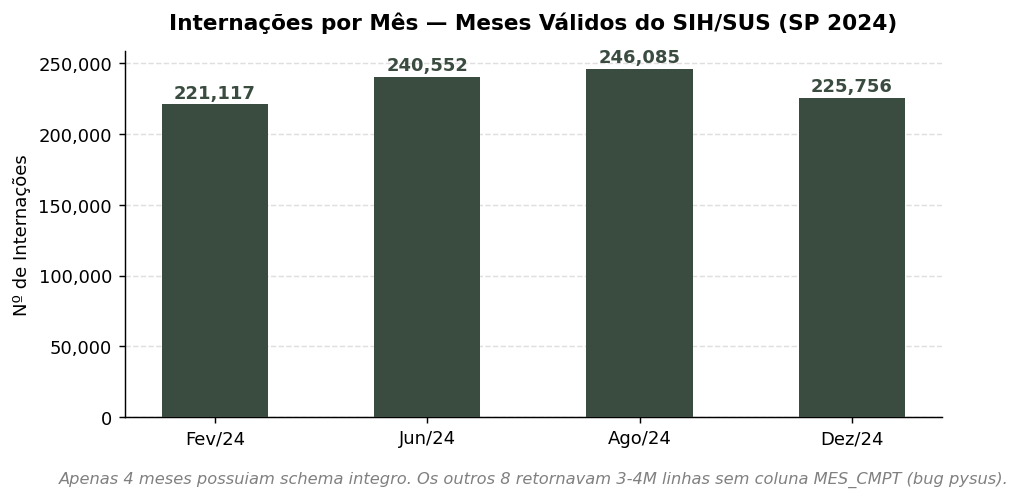

Salvo: eda_01_internacoes_por_mes.png


In [12]:
# ─── EDA 4 — Internações por mês  (-> Slide 11) ────────────
labels   = {2: 'Fev/24', 6: 'Jun/24', 8: 'Ago/24', 12: 'Dez/24'}
contagem = df.groupby('mes').size().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [labels[m] for m in contagem.index],
    contagem.values,
    color=OLIVE, width=0.5, zorder=3
)
ax.set_title('Internações por Mês — Meses Válidos do SIH/SUS (SP 2024)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Nº de Internações')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{val:,}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=OLIVE)

ax.annotate(
    'Apenas 4 meses possuiam schema integro. '
    'Os outros 8 retornavam 3-4M linhas sem coluna MES_CMPT (bug pysus).',
    xy=(0.5, -0.18), xycoords='axes fraction', ha='center',
    fontsize=9, color='gray', style='italic'
)

plt.tight_layout()
plt.savefig('eda_01_internacoes_por_mes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_01_internacoes_por_mes.png')

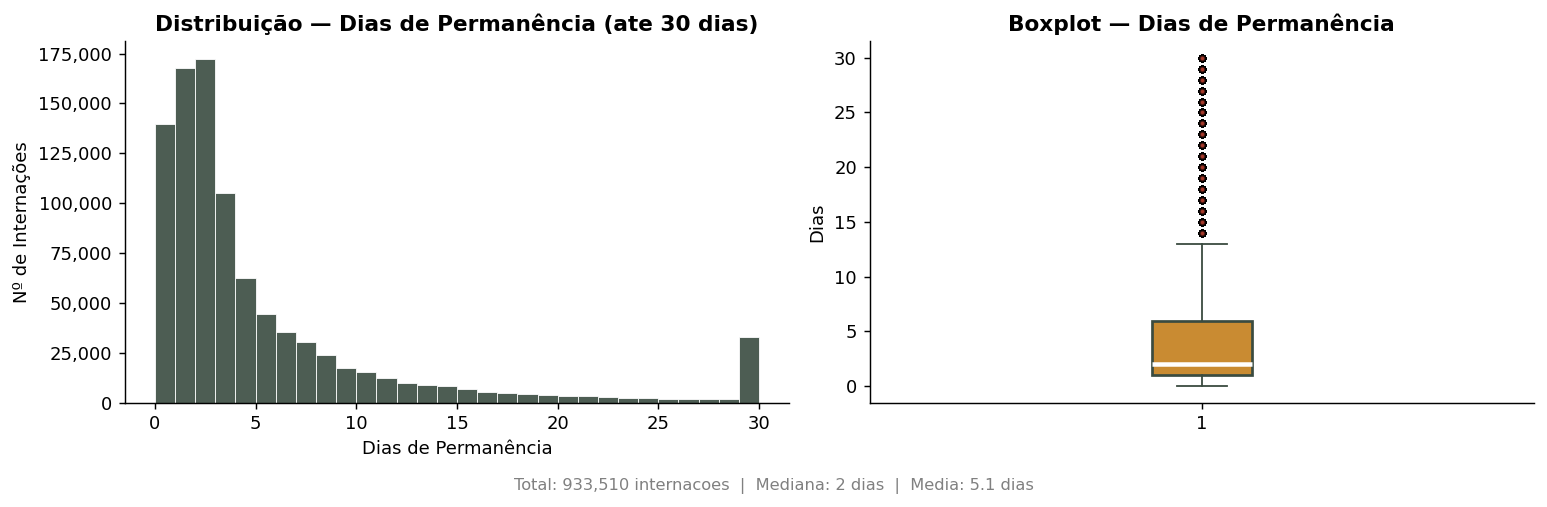

Salvo: eda_02_dias_permanencia.png


In [13]:
# ─── EDA 5 — Distribuição dias de permanência  (-> Slide 11) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

dados_clip = df['dias_permanencia'].clip(upper=30).dropna()

ax1.hist(dados_clip, bins=30, color=OLIVE, edgecolor='white',
         linewidth=0.5, alpha=0.9)
ax1.set_title('Distribuição — Dias de Permanência (ate 30 dias)',
              fontweight='bold')
ax1.set_xlabel('Dias de Permanência')
ax1.set_ylabel('Nº de Internações')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

bplot = ax2.boxplot(
    dados_clip, vert=True, patch_artist=True,
    boxprops=dict(facecolor=AMBER, color=OLIVE, linewidth=1.5),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color=OLIVE),
    capprops=dict(color=OLIVE),
    flierprops=dict(marker='o', markerfacecolor=RED,
                    markersize=3, alpha=0.3)
)
ax2.set_title('Boxplot — Dias de Permanência', fontweight='bold')
ax2.set_ylabel('Dias')

med  = df['dias_permanencia'].median()
mean = df['dias_permanencia'].mean()
fig.suptitle(
    f'Total: {len(df):,} internacoes  |  '
    f'Mediana: {med:.0f} dias  |  Media: {mean:.1f} dias',
    fontsize=9, color='gray', y=0
)

plt.tight_layout()
plt.savefig('eda_02_dias_permanencia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_02_dias_permanencia.png')

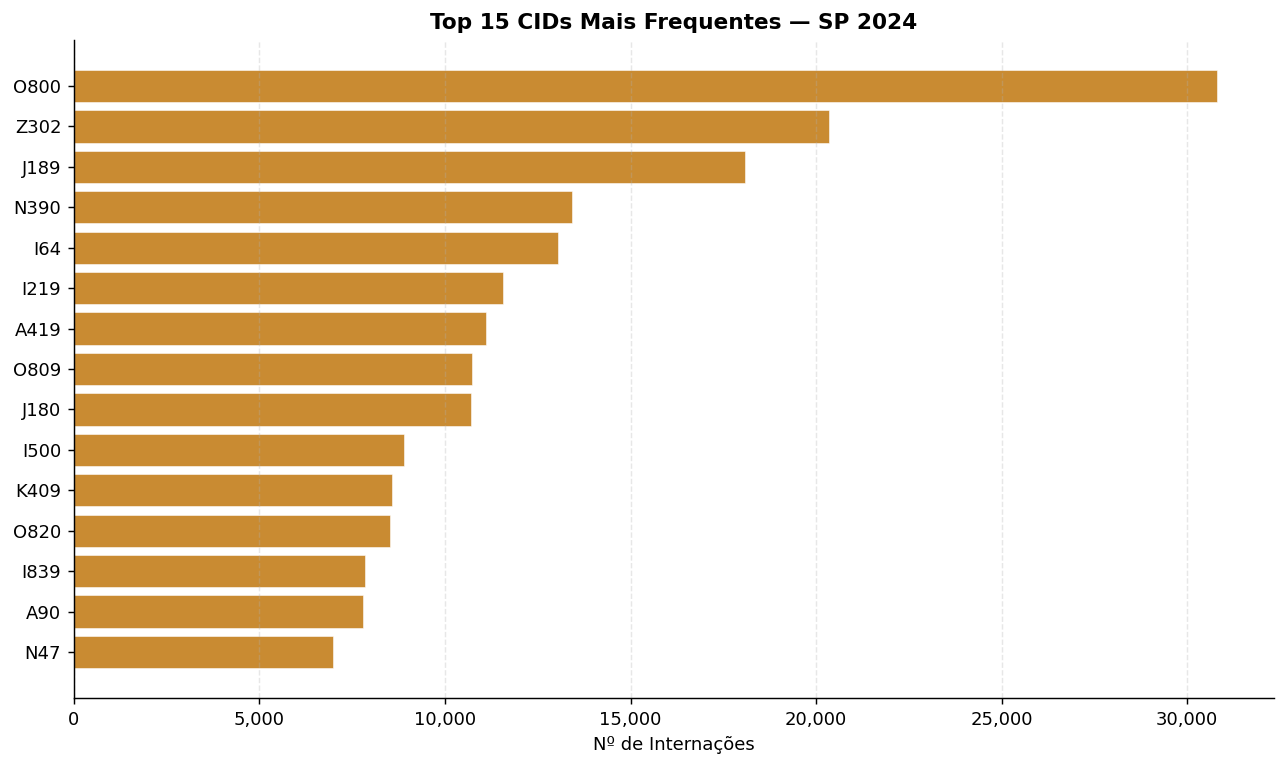

Salvo: eda_03_top_cid.png


In [14]:
# ─── EDA 6 — Top 15 CIDs mais frequentes  (-> Slide 11) ───
top = df['cid_principal'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top.index[::-1], top.values[::-1],
        color=AMBER, edgecolor='white', linewidth=0.3)
ax.set_title('Top 15 CIDs Mais Frequentes — SP 2024',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de Internações')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_03_top_cid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_03_top_cid.png')

In [15]:
# ─── EDA 7 — Taxa de evasão por município  (-> Slide 12) ──
df['evasao'] = (df['municipio_residencia'] != df['municipio_hospital']).astype(int)

evasao = (
    df.groupby('municipio_residencia')
    .agg(total=('evasao', 'count'), internou_fora=('evasao', 'sum'))
    .reset_index()
)
evasao['taxa_evasao_pct'] = (evasao['internou_fora'] / evasao['total'] * 100).round(1)

# Minimo de 50 internacoes para ter representatividade estatistica
evasao_sp = evasao[evasao['total'] >= 50].copy()

print(f'Municipios com >= 50 internacoes: {len(evasao_sp)}')
print(f'\nTop 10 maior taxa de evasao:')
display(
    evasao_sp.nlargest(10, 'taxa_evasao_pct')
    [['municipio_residencia', 'total', 'internou_fora', 'taxa_evasao_pct']]
    .rename(columns={
        'municipio_residencia': 'Cod. Municipio',
        'total': 'Total Internacoes',
        'internou_fora': 'Internadas Fora',
        'taxa_evasao_pct': 'Taxa Evasao (%)'
    })
)

Municipios com >= 50 internacoes: 659

Top 10 maior taxa de evasao:


,Cod. Municipio,Total Internacoes,Internadas Fora,Taxa Evasao (%)
12,110020,76,76,100.0
54,130260,144,144,100.0
64,140010,76,76,100.0
138,160030,111,111,100.0
193,172100,68,68,100.0
299,230440,60,60,100.0
425,280030,52,52,100.0
544,292740,76,76,100.0
695,312710,68,68,100.0
728,313420,83,83,100.0


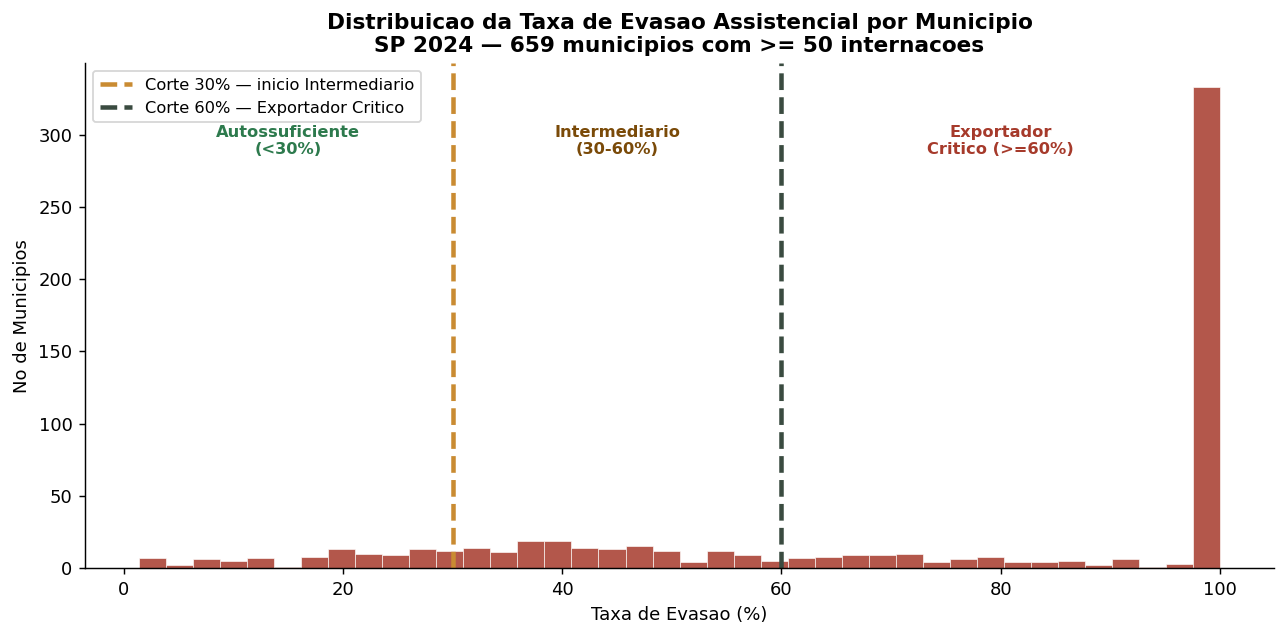

Salvo: eda_04_evasao_distribuicao.png


In [16]:
# ─── EDA 8 — Distribuição da taxa de evasão  (-> Slide 12) ─
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(evasao_sp['taxa_evasao_pct'], bins=40,
        color=RED, edgecolor='white', linewidth=0.4, alpha=0.85)

ax.axvline(30, color=AMBER, linewidth=2.5, linestyle='--',
           label='Corte 30% — inicio Intermediario')
ax.axvline(60, color=OLIVE, linewidth=2.5, linestyle='--',
           label='Corte 60% — Exportador Critico')

ax.set_title(
    f'Distribuicao da Taxa de Evasao Assistencial por Municipio\n'
    f'SP 2024 — {len(evasao_sp)} municipios com >= 50 internacoes',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Taxa de Evasao (%)')
ax.set_ylabel('No de Municipios')
ax.legend(fontsize=9)

y_max = ax.get_ylim()[1]
ax.text(15, y_max * 0.82, 'Autossuficiente\n(<30%)',
        ha='center', color=GREEN, fontweight='bold', fontsize=9)
ax.text(45, y_max * 0.82, 'Intermediario\n(30-60%)',
        ha='center', color='#7A4A08', fontweight='bold', fontsize=9)
ax.text(80, y_max * 0.82, 'Exportador\nCritico (>=60%)',
        ha='center', color=RED, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('eda_04_evasao_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_04_evasao_distribuicao.png')

=== RESULTADO DO MODELO DE SEGMENTACAO ===
  Exportador Critico    :  419 municipios  (63.6%)
  Intermediario         :  154 municipios  (23.4%)
  Autossuficiente       :   86 municipios  (13.1%)
  TOTAL                 :  659 municipios


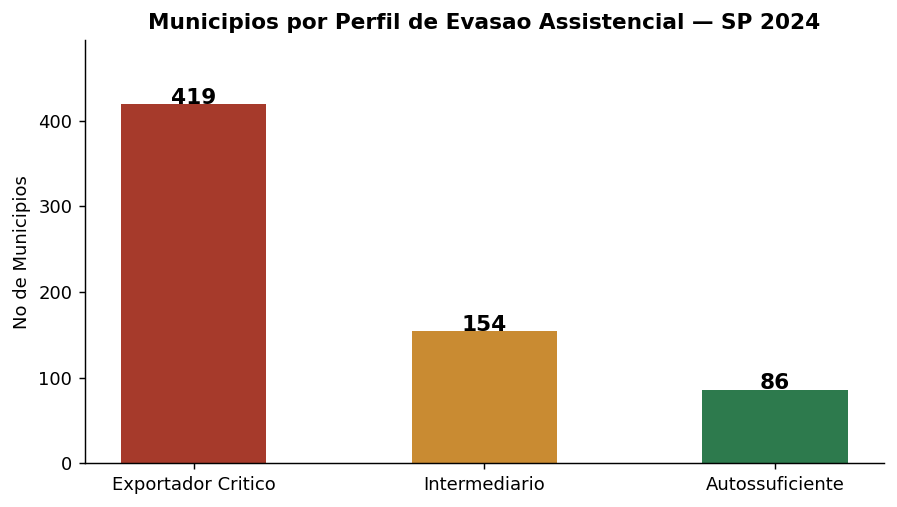

Salvo: eda_05_perfis_municipios.png


In [17]:
# ─── EDA 9 — Classificacao em 3 perfis  (-> Slide 12) ──────
def classificar(taxa):
    if taxa < 30:  return 'Autossuficiente'
    if taxa < 60:  return 'Intermediario'
    return 'Exportador Critico'

evasao_sp['perfil'] = evasao_sp['taxa_evasao_pct'].apply(classificar)
contagem = evasao_sp['perfil'].value_counts()

print('=== RESULTADO DO MODELO DE SEGMENTACAO ===')
for perfil, n in contagem.items():
    pct = n / len(evasao_sp) * 100
    print(f'  {perfil:<22}: {n:>4} municipios  ({pct:.1f}%)')
print(f'  {"TOTAL":<22}: {len(evasao_sp):>4} municipios')

cores  = {'Autossuficiente': GREEN, 'Intermediario': AMBER, 'Exportador Critico': RED}
ordem  = ['Exportador Critico', 'Intermediario', 'Autossuficiente']
vals   = [contagem.get(p, 0) for p in ordem]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ordem, vals,
              color=[cores[p] for p in ordem], width=0.5)
ax.set_title('Municipios por Perfil de Evasao Assistencial — SP 2024',
             fontweight='bold')
ax.set_ylabel('No de Municipios')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(vals) * 1.18)

plt.tight_layout()
plt.savefig('eda_05_perfis_municipios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_05_perfis_municipios.png')

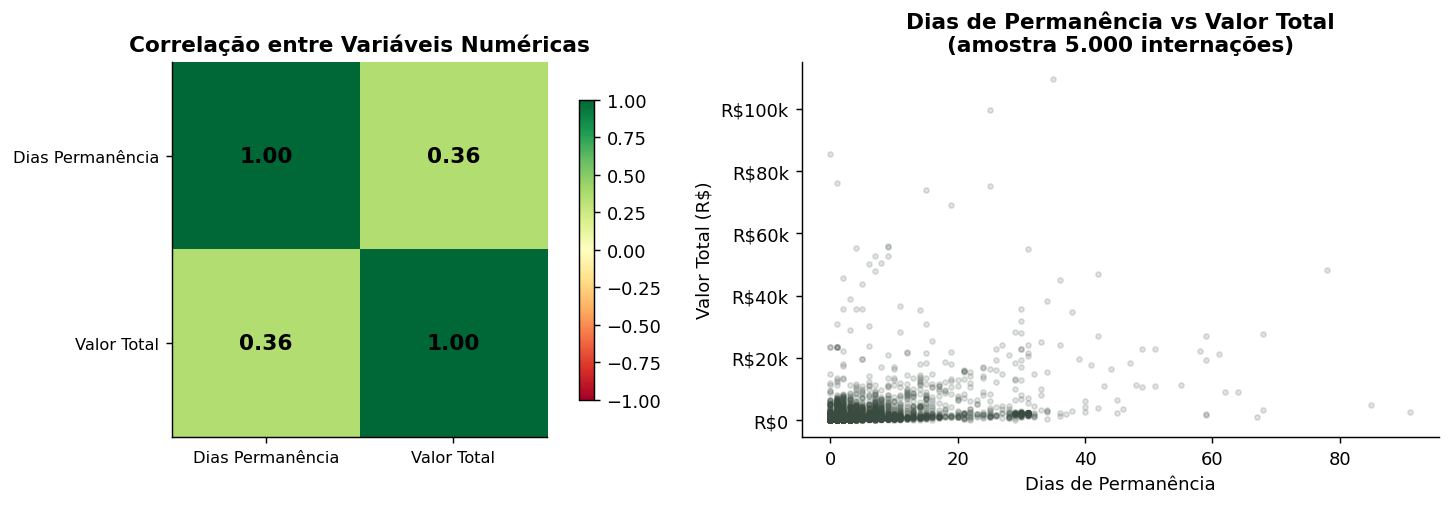

Salvo: eda_03b_correlacao.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np

cols_num = ['dias_permanencia', 'valor_total']
corr = df[cols_num].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap de correlação
im = ax1.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_xticks(range(len(cols_num)))
ax1.set_yticks(range(len(cols_num)))
ax1.set_xticklabels(['Dias Permanência', 'Valor Total'], fontsize=9)
ax1.set_yticklabels(['Dias Permanência', 'Valor Total'], fontsize=9)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{corr.iloc[i,j]:.2f}',
                 ha='center', va='center', fontweight='bold', fontsize=12)
ax1.set_title('Correlação entre Variáveis Numéricas', fontweight='bold')
plt.colorbar(im, ax=ax1, shrink=0.8)

# Scatter dias_permanencia x valor_total (amostra para não travar)
amostra = df[['dias_permanencia', 'valor_total']].dropna().sample(5000, random_state=42)
ax2.scatter(amostra['dias_permanencia'], amostra['valor_total'],
            alpha=0.15, s=8, color='#3A4B40')
ax2.set_xlabel('Dias de Permanência')
ax2.set_ylabel('Valor Total (R$)')
ax2.set_title('Dias de Permanência vs Valor Total\n(amostra 5.000 internações)',
              fontweight='bold')
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k' if x >= 1000 else f'R${x:.0f}')
)

plt.tight_layout()
plt.savefig('eda_03b_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: eda_03b_correlacao.png')

In [ ]:
# ─── EDA 11 — Modelo Analítico: K-Means (k=3) ───────────────────────────────
# Valida empiricamente os cortes 30 % / 60 % usando clustering nao supervisionado.
# Roda APÓS EDA 7 (evasao_sp) e EDA 9 (coluna 'perfil').

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ── 1. Enriquecer evasao_sp com medias por municipio ─────────────────────────
medias = df.groupby("municipio_residencia").agg(
    dias_medio  = ("dias_permanencia", "mean"),
    valor_medio = ("valor_total",      "mean"),
).reset_index()

base = evasao_sp.merge(medias, on="municipio_residencia", how="left")
base[["dias_medio", "valor_medio"]] = base[["dias_medio", "valor_medio"]].fillna(0)

# ── 2. Features e normalizacao ────────────────────────────────────────────────
FEATURES = ["taxa_evasao_pct", "total", "dias_medio", "valor_medio"]
X = StandardScaler().fit_transform(base[FEATURES].values)

# ── 3. Elbow + Silhouette para justificar k=3 ─────────────────────────────────
ks        = range(2, 8)
inercias  = []
silhuetas = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X, lb))

# ── 4. Modelo final k=3 ───────────────────────────────────────────────────────
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
base["cluster"] = km3.fit_predict(X)
sil3 = silhouette_score(X, base["cluster"])

# Mapeia cluster -> nome pelo menor->maior taxa_evasao_pct media
ordem = (
    base.groupby("cluster")["taxa_evasao_pct"]
    .mean().sort_values().index.tolist()
)
NOMES = {
    ordem[0]: "Autossuficiente",
    ordem[1]: "Intermediario",
    ordem[2]: "Exportador Critico",
}
base["cluster_nome"] = base["cluster"].map(NOMES)

concordancia = (base["cluster_nome"] == base["perfil"]).mean() * 100

print("=== K-MEANS (k=3) — MODELO ANALITICO ===")
print(f"Silhouette Score : {sil3:.3f}   (0=ruim | 1=perfeito)")
print(f"Inertia          : {km3.inertia_:,.0f}")
print(f"Concordancia c/  regras empiricas : {concordancia:.1f}%\n")

perfil_tbl = base.groupby("cluster_nome")[FEATURES].mean().round(1)
perfil_tbl["n_municipios"] = base["cluster_nome"].value_counts()
print("Perfil medio por cluster:")
print(perfil_tbl[["taxa_evasao_pct","dias_medio","valor_medio","n_municipios"]].to_string())

# ── 5. Visualizacoes ──────────────────────────────────────────────────────────
COR = {"Autossuficiente": "#3A4B40", "Intermediario": "#C98B32", "Exportador Critico": "#C0392B"}
ORDEM_PERFIS = ["Autossuficiente", "Intermediario", "Exportador Critico"]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.36)

# — Elbow
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(list(ks), inercias, "o-", color="#3A4B40", linewidth=2, markersize=7)
ax0.axvline(3, color="#C98B32", linestyle="--", linewidth=1.5, alpha=0.9)
ax0.set_title("Elbow Curve — Inertia", fontweight="bold")
ax0.set_xlabel("k  (numero de clusters)")
ax0.set_ylabel("Inertia")
ax0.annotate("k = 3", xy=(3, inercias[1]), xytext=(3.25, inercias[0]*0.96),
             color="#C98B32", fontweight="bold", fontsize=10)

# — Silhouette por k
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(list(ks), silhuetas, "s-", color="#526358", linewidth=2, markersize=7)
ax1.axvline(3, color="#C98B32", linestyle="--", linewidth=1.5, alpha=0.9)
ax1.set_title("Silhouette Score por k", fontweight="bold")
ax1.set_xlabel("k  (numero de clusters)")
ax1.set_ylabel("Silhouette Score")
ax1.annotate(f"k=3: {silhuetas[1]:.3f}", xy=(3, silhuetas[1]),
             xytext=(3.2, silhuetas[1] + 0.01),
             color="#C98B32", fontweight="bold", fontsize=10)

# — Scatter: taxa_evasao x valor_medio
ax2 = fig.add_subplot(gs[0, 2])
for nome, grp in base.groupby("cluster_nome"):
    ax2.scatter(grp["taxa_evasao_pct"], grp["valor_medio"],
                label=nome, color=COR[nome], alpha=0.72,
                s=45, edgecolors="white", linewidth=0.4)
ax2.set_title("Clusters: Taxa Evasao × Valor Medio", fontweight="bold")
ax2.set_xlabel("Taxa de Evasao (%)")
ax2.set_ylabel("Valor Medio por Internacao (R$)")
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k" if x >= 1000 else f"R${x:.0f}")
)
ax2.legend(fontsize=8, loc="upper right")

# — Barras comparativas: K-Means vs Regras
ax3 = fig.add_subplot(gs[1, :2])
n_km  = [base[base["cluster_nome"] == p].shape[0] for p in ORDEM_PERFIS]
n_reg = [base[base["perfil"]       == p].shape[0] for p in ORDEM_PERFIS]
x = np.arange(len(ORDEM_PERFIS))
w = 0.36
b1 = ax3.bar(x - w/2, n_km,  w, label="K-Means",
             color=[COR[p] for p in ORDEM_PERFIS])
b2 = ax3.bar(x + w/2, n_reg, w, label="Regras Empiricas",
             color=[COR[p] for p in ORDEM_PERFIS], alpha=0.40)
ax3.set_xticks(x)
ax3.set_xticklabels(ORDEM_PERFIS, fontsize=10)
ax3.set_ylabel("No de Municipios")
ax3.set_title(
    f"Comparacao: K-Means vs Regras Empiricas  |  Concordancia: {concordancia:.1f}%",
    fontweight="bold"
)
ax3.legend()
for bar, v in zip(b1, n_km):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(v), ha="center", fontsize=9, fontweight="bold")
for bar, v in zip(b2, n_reg):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(v), ha="center", fontsize=9, color="#666")

# — Metricas (painel texto)
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")
resumo = (
    "METRICAS DO MODELO\n"
    "─────────────────────\n"
    "Algoritmo  : K-Means\n"
    "k          : 3 clusters\n"
    "\nFeatures (4):\n"
    "  taxa_evasao_pct\n"
    "  total internacoes\n"
    "  dias_permanencia medio\n"
    "  valor_total medio\n"
    "\n─────────────────────\n"
    f"Silhouette : {sil3:.3f}\n"
    f"Inertia    : {km3.inertia_:,.0f}\n"
    "\n─────────────────────\n"
    f"Concordancia\n"
    f"c/ regras  : {concordancia:.1f}%\n"
    "\n─────────────────────\n"
    f"Municipios : {len(base)}\n"
    "Base       : 933.510\n"
    "           internacoes"
)
ax4.text(0.05, 0.97, resumo, transform=ax4.transAxes,
         fontsize=9, va="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6",
                   facecolor="#F5F0E8", edgecolor="#3A4B40", linewidth=1.5))

plt.suptitle(
    "Modelo K-Means — Segmentacao de Municipios por Evasao Assistencial · SP 2024",
    fontweight="bold", fontsize=13, y=1.01
)
plt.savefig("eda_11_kmeans_modelo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: eda_11_kmeans_modelo.png")
